In [1]:
# Analiz və vizualizasiya üçün kitabxanaların yüklənməsi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

# Datasetin yüklənməsi
df=pd.read_csv('cars.csv',sep=',')

Saving cars.csv to cars.csv


# Datasetə ümumi baxış

In [3]:
df.head()
#ilk 5 sətir

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,...,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,Hyundai i30,15000.0,AZN,"Bakı, dünən 23:28",bakı,13.09.2024,23:28,...,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,270 000 km,Ön,Bakı,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,LADA (VAZ) Niva Travel,23700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,...,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Bəli,5,0 km,Tam,Bakı,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,Toyota Land Cruiser,35600.0,$,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,...,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,8+,164 750 km,Tam,Bakı,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,Hyundai Elantra,26700.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,...,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,NaN,126 000 km,Ön,Bakı,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyota-prius,2024-09-13 20:32:19.751157+00,Toyota Prius,10500.0,AZN,"Bakı, dünən 23:59",bakı,13.09.2024,23:59,...,Variator,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,354 000 km,Ön,Bakı,82078856-0d07-4a0d-8123-69c2e5002e07,/autos/8674773-toyota-prius,Arxa görüntü kamerası


In [4]:
df.shape
#datasetin ölçüsü (sətir,sütun)

(653721, 56)

Dataset 56 sütundan və 653721 sətirdən ibarətdir.

# Sütun başlıqlarına və dəyərlərinə baxış

In [5]:
df.columns
#sütun başlıqlarına ümumi baxış

Index(['id_x', 'car_rel_url_x', 'datetime_scrape', 'name', 'price_x',
       'currency_x', 'datetime_product', 'city', 'day', 'hour', 'attributes',
       'production_year', 'engine_displacement_num',
       'engine_displacement_unit', 'kilometrage_num', 'kilometrage_unit',
       'barter', 'loan', 'salon', 'spare_parts', 'vip', 'featured', 'img_url',
       'id_y', 'cars_id', 'car_rel_url_y', 'datetime', 'description',
       'price_y', 'currency_y', 'owner_name', 'shop_name', 'phone', 'updated',
       'views', 'vin', 'car_details_id_x', 'Ban növü', 'Buraxılış ili',
       'Hansı bazar üçün yığılıb', 'Marka', 'Model', 'Mühərrik', 'Qəzalı',
       'Rəng', 'Sahiblər', 'Sürətlər qutusu', 'Vəziyyəti', 'Yeni',
       'Yerlərin sayı', 'Yürüş', 'Ötürücü', 'Şəhər', 'car_details_id_y',
       'car_rel_url', 'extra_info'],
      dtype='object')

Datasetdə ümumi olaraq datalar azərbaycanca yazılıb, lakin bəzi sütun başlıqları ingiliscə adlandırılıb. Həmin sütun adlarını azərbaycanca yazıb datanı daha təmiz hala gətirməliyik. Amma əvvəlcə prosesi daha da aydınlaşdırmaq üçün sütunda "x" və "y" ilə fərqləndirilən sütunların eyni olub-olmamasını yoxlayaq.

In [6]:
id=(df['id_x'] == df['id_y']).all()
car_rel_url=(df['car_rel_url_x'] == df['car_rel_url_y']).all()
price=(df['price_x'] == df['price_y']).all()
currency=(df['currency_x'] == df['currency_y']).all()
details=(df['car_details_id_x'] == df['car_details_id_y']).all()

print(f"id: {id}")
print(f"car_rel_url: {car_rel_url}")
print(f"price: {price}")
print(f"currency: {currency}")
print(f"details: {details}")

id: False
car_rel_url: False
price: False
currency: False
details: True


Biraz daha araşdıraq:

In [7]:
df[['id_x','id_y','car_rel_url_x','car_rel_url_y','price_x','price_y','currency_x','currency_y','car_details_id_x','car_details_id_y']].head()

,id_x,id_y,car_rel_url_x,car_rel_url_y,price_x,price_y,currency_x,currency_y,car_details_id_x,car_details_id_y
0,3c234145-d57a-4ad6-9448-d43810fc3392,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,/autos/8748840-hyundai-i30,/autos/8748840-hyundai-i30,15000.0,15000.0,AZN,AZN,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,8d84d800-fafd-4d5c-b640-f47bd6c5ac20
1,c74ea36f-6be1-4de4-926d-e117197dcf00,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,/autos/8475807-lada-vaz-niva-travel,/autos/8475807-lada-vaz-niva-travel,23700.0,23700.0,AZN,AZN,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,2cf8b84b-adaf-467a-8f06-3dabcf866c8a
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,22bb3704-ebe7-4357-ba2f-1806d1a7042b,/autos/8739686-toyota-land-cruiser,/autos/8739686-toyota-land-cruiser,35600.0,35600.0,$,USD,22bb3704-ebe7-4357-ba2f-1806d1a7042b,22bb3704-ebe7-4357-ba2f-1806d1a7042b
3,459cc337-fb63-48de-9694-41554923d311,e0d16dac-4091-4417-916e-cadeff600f95,/autos/8712597-hyundai-elantra,/autos/8712597-hyundai-elantra,26700.0,26700.0,AZN,AZN,e0d16dac-4091-4417-916e-cadeff600f95,e0d16dac-4091-4417-916e-cadeff600f95
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,82078856-0d07-4a0d-8123-69c2e5002e07,/autos/8674773-toyota-prius,/autos/8674773-toyota-prius,10500.0,10500.0,AZN,AZN,82078856-0d07-4a0d-8123-69c2e5002e07,82078856-0d07-4a0d-8123-69c2e5002e07


Sətirlərdə bərabər dəyərlərin olduğunu görürük, araşdıraq:

In [8]:
id=(df['id_x'] == df['id_y']).sum()
car_rel_url=(df['car_rel_url_x'] == df['car_rel_url_y']).sum()
price=(df['price_x'] == df['price_y']).sum()
currency=(df['currency_x'] == df['currency_y']).sum()
details=(df['car_details_id_x'] == df['car_details_id_y']).sum()

print(f"id: {id}")
print(f"car_rel_url: {car_rel_url}")
print(f"price: {price}")
print(f"currency: {currency}")
print(f"details: {details}")

id: 0
car_rel_url: 653719
price: 653422
currency: 465591
details: 653721


Datasetin 653721 sətirlik olduğunu nəzərə alsaq, id'lərin fərqli, details sütunlarının isə birəbir eyni olduğu açıq aşkar görünür. Price sütununa gəldikdə isə datalar yenidən toplandıqda avtomobilin qiyməti artmış, azalmış və ya heç dəyişməmiş ola bilər, bu da onlar arasındakı fərqi izah edir. Currency sütununa diqqətlə baxdıqda görürük ki, valyuta sütunlardan birində 'USD', digərində isə '$' olaraq qeyd olunub. Lakin əsas diqqət çəkən car_rel_url sütunlarının sadəcə 2-sinin fərqli olmasıdır. Bu hissəni araşdıraq:

In [9]:
df[df['car_rel_url_x'] != df['car_rel_url_y']]

,id_x,car_rel_url_x,datetime_scrape,name,price_x,currency_x,datetime_product,city,day,hour,...,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş,Ötürücü,Şəhər,car_details_id_y,car_rel_url,extra_info
76248,af041463-ca2b-4ea9-b766-a3bcffd8e6cc,/autos/8811551-bmw-530,2024-09-25 04:46:35.641859+00,BMW 530,24500.0,AZN,"Bakı, dünən 21:41",bakı,24.09.2024,21:41,...,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,255 000 km,Arxa,Bakı,15824947-4034-46ce-91f3-10cb9fd80533,/autos/8811551-bmw-528,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
76814,83171397-b038-4953-a670-a688a6e0082a,/autos/8807612-mercedes-e-220-d,2024-09-25 04:46:35.641859+00,Mercedes E 220 d,24500.0,AZN,"Bakı, dünən 19:37",bakı,24.09.2024,19:37,...,Avtomat,"Vuruğu yoxdur, rənglənməyib",Xeyr,5,250 000 km,Arxa,Bakı,c4e171c4-28d4-4c8d-9cfd-6e5c48ec5a45,/autos/8807612-mercedes-e-250,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...


Aradakı fərq avtomobilin markası ilə bağlıdır, sütunların düzgünlüyünü yoxlayaq:

In [10]:
df.loc[
    df["car_rel_url_x"] != df["car_rel_url_y"],
    ["name", "car_rel_url_x", "car_rel_url_y", "price_x"]
]

,name,car_rel_url_x,car_rel_url_y,price_x
76248,BMW 530,/autos/8811551-bmw-530,/autos/8811551-bmw-528,24500.0
76814,Mercedes E 220 d,/autos/8807612-mercedes-e-220-d,/autos/8807612-mercedes-e-250,24500.0


Avtomobilin adına əsasən car_rel_url_x sütununun doğru olduğunu, digər sütunda isə məlumat uyğunsuzluğu olduğunu müşahidə edirik.

Son olaraq car_rel_url sütununa baxaq:

In [11]:
x=(df['car_rel_url'] == df['car_rel_url_x']).all()
y=(df['car_rel_url'] == df['car_rel_url_y']).all()

print(f"Avtomobil_URL_1: {x}")
print(f"Avtomobil_URL_2: {y}")

Avtomobil_URL_1: False
Avtomobil_URL_2: True


car_rel_url sütunu "y"  sütunu ilə eyni olduğu üçün məlumatların hər iki sütunda yanlış yazıldığını deyə bilərik. Ona görə də ən düzgün sütun olan car_rel_url_x sütununu saxlayırıq digər iki sütunu isə silirik.

Həmçinin car_details_id sütunu duplicate sütun olduğuna görə birini silirik.

In [12]:
df.drop(columns=['car_rel_url_y', 'car_rel_url','car_details_id_y'], inplace=True)

Qiymət dəyişikliyə valyutanın təsiri olub-olmadığını yoxlayaq:

In [13]:
df["currency_x"] = df["currency_x"].replace({
    "$": "USD",
    "€": "EUR"
})

In [14]:
currency=(df['currency_x'] == df['currency_y']).sum()

print(f"currency: {currency}")

currency: 653708


Valyuta dəyərlərini eyniləşdirdikdən sonra hələ də fərqliliklər var. Səbəbini araşdıraq:

In [15]:
df.loc[
    df["currency_x"] != df["currency_y"],
    ["price_x", "currency_x", "price_y", "currency_y", "car_rel_url_x", "description"]
]

,price_x,currency_x,price_y,currency_y,car_rel_url_x,description
54005,65900.0,AZN,65900.0,USD,/autos/8803017-land-rover-range-rover,{}
77773,27900.0,USD,45000.0,AZN,/autos/8773717-toyota-land-cruiser-prado,"{""Toyota Bakidan alinib daima servizde qulluq ..."
81120,27700.0,USD,48800.0,AZN,/autos/8768348-kia-stinger,"{""Azn odeniwi ile Hazir kreditde satilir. Ilki..."
167422,29500.0,USD,48500.0,AZN,/autos/8639618-hyundai-sonata,Salam masin olkeye yeni gelib zavot braxlisi 2...
172357,31800.0,AZN,17700.0,USD,/autos/8821085-bmw-328,Mawin Super veziyyetdedir zavod Qirmizi salon ...
217636,27900.0,AZN,20000.0,USD,/autos/8821762-bmw-528,Maşın yeni gəlib özüm üçün gətirdiyim maşındı ...
305642,30900.0,USD,52500.0,AZN,/autos/8829666-bmw-x5,Zavod M Tech\nMaşın ideal vəziyyətdədir istəni...
383336,51000.0,AZN,30000.0,USD,/autos/8880639-bmw-530,Şexsi maşınımdır.BMW 530 i.Bezkraska 2017 ci i...
419599,36900.0,AZN,21700.0,USD,/autos/8941962-bmw-528,Təmiz M tec heçbir problemi yoxdur otur sür ma...
478903,28900.0,EUR,28900.0,USD,/autos/8963979-toyota-land-cruiser-prado,AvtomobiL modeL oLaraq 2014 modeLdi. Birinci s...


Valyuta fərqləri məbləğ fərqlərində də əks olunub. Yalnız bir sətirdə məbləğ eyni olsa da, valyutalar fərqlidi. Elanın saytına baxdıqdan sonra original valyuta dəyərinin AZN olduğunu müşahidə etdim. USD üzrə qiymətini hesablayaq:

In [16]:
# 1 USD ≈ 1.70 AZN
df.loc[54005, "price_y"] = round(df.loc[54005, "price_y"] / 1.70, 1)

Currency və price sütunları bir-biri ilə əlaqəli sütunlar olduğu üçün onlar arasındakı uyğunsuzluğu aradan qaldırdıq, hər iki sütun olduğu kimi qalır.

"city" sütunu "Şəhər" olaraq adlanan sütunun ingiliscə adlandırılan versiyasıdır, hər iki sütun şəhərin adını göstərir. Sütunlara daha dəqiq baxsaq:

In [17]:
df[['city', 'Şəhər']]

,city,Şəhər
0,bakı,Bakı
1,bakı,Bakı
2,bakı,Bakı
3,bakı,Bakı
4,bakı,Bakı
...,...,...
653716,bakı,Bakı
653717,göygöl,Göygöl
653718,bakı,Bakı
653719,kürdəmir,Kürdəmir


Göründüyü kimi dəyərlər eynidi "city" sütununu silib "Şəhər" sütununu saxlayırıq. Çünki bu həm bizə sütun adlarını yenidən adlandırdıqda üstüklükdür, həm də şəhər adları orfoqrafik qaydaya uyğun şəkildə daha düzgün yazılıb.

In [18]:
df.drop(columns=['city'], inplace=True)

"production_year" sütunu "Buraxılış ili" olaraq adlanan sütunun ingiliscə adlandırılan versiyasıdır, hər iki sütun avtomobilin istehsal tarixini göstərir. Sütunlara daha dəqiq baxsaq:

In [19]:
production=(df['Buraxılış ili'] == df['production_year']).all()

print(f"production: {production}")

production: False


In [20]:
production=(df['Buraxılış ili'] != df['production_year']).sum()

print(f"production: {production}")

production: 5792


İki sütun arasında fərqlər var onları araşdıraq:

In [21]:
df.loc[
    df["Buraxılış ili"] != df["production_year"],
    ["name", "Buraxılış ili", "production_year", "Marka", "Model"]
]

,name,Buraxılış ili,production_year,Marka,Model
21495,Kia Sorento,2003,2023,Kia,Sorento
77769,Lexus GX 460,2017,2016,Lexus,GX 460
78874,BMW 528,2013,2014,BMW,528
183725,Ford Fusion (North America),2020,2015,Ford,Fusion (North America)
434384,Chery eQ7,2024,0,Chery,eQ7
...,...,...,...,...,...
653355,Tufan M50,2020,0,Tufan,M50
653411,Kia EV6,2021,0,Kia,EV6
653485,BYD Yuan Plus,2024,0,BYD,Yuan Plus
653604,Vespa Sprint 150,2023,0,Vespa,Sprint 150


Sütunlara baxdıqda "production_year" sütununda "0" olaraq qeyd olunan illər görürük. Bu data etibarsızdır il "0" ola bilməz, deməli "Buraxılış ili" sütunundakı datalar daha düzgündür. Ona görə "Buraxılış ili" sütununu saxlayıb "production_year" sütununu silirik.

In [22]:
df.drop(columns=['production_year'], inplace=True)

"kilometrage_num" sütunu "Yürüş" olaraq adlanan sütunun ingiliscə adlandırılan versiyasıdır, hər iki sütun avtomobilin yürüş məsafəsini göstərir. Sütunlara daha dəqiq baxsaq:

In [23]:
yürüş_num = (
    df["Yürüş"]
    .str.replace("km", "", regex=False)
    .str.replace(" ", "", regex=False)
    .astype(float)
)

kilometr = (df["kilometrage_num"] == yürüş_num).all()

print(f"kilometr: {kilometr}")

kilometr: False


"Yürüş" sütunu "km" ilə birlikdə yazıldığı üçün ədəd hissəsini ayrıca çıxarıb sonra yoxlayırıq.

In [24]:
kilometr = (df["kilometrage_num"] != yürüş_num).sum()

print(f"kilometr: {kilometr}")

kilometr: 1832


In [25]:
df.loc[
    df["kilometrage_num"] != yürüş_num,
    [
        "name", "Yürüş", "kilometrage_num", "kilometrage_unit", "Marka", "Model"]
    ]

,name,Yürüş,kilometrage_num,kilometrage_unit,Marka,Model
76949,Kia Sorento,88 000 km,179000,km,Kia,Sorento
77458,Mitsubishi Outlander,171 000 km,270000,km,Mitsubishi,Outlander
79587,Opel Astra,590 000 km,270000,km,Opel,Astra
82731,Ssang Yong Tivoli,112 000 km,112,km,Ssang Yong,Tivoli
82738,Lincoln MKZ,180 000 km,179000,km,Lincoln,MKZ
...,...,...,...,...,...,...
653188,Keeway Superlight 200,36 000 km,0,NaN,Keeway,Superlight 200
653322,Porsche Taycan 4S,36 000 km,0,NaN,Porsche,Taycan 4S
653355,Tufan M50,18 000 km,0,NaN,Tufan,M50
653411,Kia EV6,16 000 km,0,NaN,Kia,EV6


"Yürüş" sütunu data haqqında daha dolğun məlumatlara sahibdir. "kilometrage_num" sütununda "0" olaraq qeyd olunan dəyərlər var, eyni dəyərlər "kilometrage_unit" olaraq da "NaN" olaraq qeyd olunub. "Yürüş" sütununu saxlıyıb "kilometrage_num" və "kilometrage_unit" sütununu silirik.

In [26]:
df.drop(columns=['kilometrage_num', 'kilometrage_unit'], inplace=True)

"spare_parts" sütunu "Qəzalı" olaraq adlanan sütunun ingiliscə adlandırılan versiyasıdır, hər iki sütun avtomobilin qəzalı olub-olmamasını göstərir. Sütunlara daha dəqiq baxsaq:

In [27]:
df['Qəzalı'].value_counts(dropna=False)

,count
Qəzalı,
NaN,651960
Bəli,1761


In [28]:
df['spare_parts'].value_counts(dropna=False)

,count
spare_parts,
NaN,651959
Qəzalı,1762


Bu sütunlardakı dəyişənlər binary kateqorik dəyişənlərdir. Data toplanan zaman qəzalı avtomobillər olunub digərləri boş qoyulduğu üçün "NaN" olaraq düşüb. "spare_parts" sütunundakı "NaN" dəyərlər "Qəzalı" sütununa nisbətən az olduğu üçün bu sütunu saxlayıb, "Qəzalı" sütununu silirik.

In [29]:
df.drop(columns=['Qəzalı'], inplace=True)

Tarix sütunlarına baxaq:

In [30]:
df[['datetime_scrape','datetime_product','day','hour','datetime','updated']]

,datetime_scrape,datetime_product,day,hour,datetime,updated
0,2024-09-13 20:32:19.751157+00,"Bakı, dünən 23:28",13.09.2024,23:28,2024-09-13 20:40:28.618345+00,13.09.2024
1,2024-09-13 20:32:19.751157+00,"Bakı, dünən 23:59",13.09.2024,23:59,2024-09-13 20:40:28.618345+00,13.09.2024
2,2024-09-13 20:32:19.751157+00,"Bakı, dünən 23:59",13.09.2024,23:59,2024-09-13 20:40:28.618345+00,13.09.2024
3,2024-09-13 20:32:19.751157+00,"Bakı, dünən 23:59",13.09.2024,23:59,2024-09-13 20:40:28.618345+00,13.09.2024
4,2024-09-13 20:32:19.751157+00,"Bakı, dünən 23:59",13.09.2024,23:59,2024-09-13 20:40:28.618345+00,13.09.2024
...,...,...,...,...,...,...
653716,2025-01-05 20:15:21.051803,"Bakı, dünən 00:03",05.01.2025,00:03,2025-01-05 20:23:28.915653,05.01.2025
653717,2025-01-05 20:15:21.051803,"Göygöl, dünən 00:32",05.01.2025,00:32,2025-01-05 20:23:28.915653,05.01.2025
653718,2025-01-05 20:15:21.051803,"Bakı, dünən 00:00",05.01.2025,00:00,2025-01-05 20:23:28.915653,05.01.2025
653719,2025-01-05 20:15:21.051803,"Kürdəmir, dünən 09:02",05.01.2025,09:02,2025-01-05 20:23:28.915653,05.01.2025


"datetime_scrape", "datetime_product" eyni tarix üzrə dataları saxlayır. "day" və "hour" sütunları isə sütunun detallara ayrılmış hissəsidi. "datetime_scrape" sütunu günün tarixini düzgün saxlasa da, saat bütün sətirlərə avtomatik yazılıb və etibarsızdır. "datetime_product" sütunu isə saatı düzgün saxlayıb tarix avtomatik yazılıb (dünən). Hər iki sütunun doğru məlumatları "day" və "hour" sütunlarında öz əksini tapıb. Buna görə də bu iki sütunu silib "hour" və "day" sütunlarını - ən düzgün məlumatları saxlayırıq.

"datetime" sütununa gəldikdə isə tarix gün olaraq doğru yazılıb, amma saatlar avtomatik doldurulub və "datetime_scrape" sütununda olduğu kimi etibarsızdır. Bu sütunda qeyd olunan doğru məlumat "updated" sütununda öz əksini tapdığına görə sütun yararlılığını itirir, ona görə də bu sütunu silə bilərik.

"datetime_product" sütununda tarixlə yanaşı "şəhər" məlumatları da var. Bu sütunu silməmişdən əvvəl "şəhər" sütunundakı null dəyərləri yoxlayaq:

In [31]:
df['Şəhər'].isna().sum()

np.int64(0)

"Şəhər" sütununda heçbir null dəyər yoxdur, deməli "datetime_product" sütununu istifadə edərək dolduracağımız əksik data yoxdur, bu sütunu silə bilərik.

In [32]:
df.drop(columns=['datetime_scrape', 'datetime_product', 'datetime'], inplace=True)

Duplicate sütunlar təmizləndikdən sonra sütun adlarını düzgün hala salaq.

In [33]:
df.rename(columns={
    "id_x": "ID_1",
    "car_rel_url_x": "Elan_linki",
    "name": "Avtomobil_adı",
    "price_x": "Qiymət_1",
    "currency_x": "Valyuta_1",
    "day": "Gün",
    "hour": "Saat",
    "attributes": "Məlumatlar",
    "engine_displacement_num": "Mühərrik_həcmi",
    "engine_displacement_unit": "Mühərrik_həcm_vahidi",
    "barter": "Barter",
    "loan": "Kredit",
    "salon": "Salon",
    "spare_parts": "Qəzalı",
    "vip": "VIP_elan",
    "featured": "Önə_çıxarılmış_elan",
    "Hansı bazar üçün yığılıb": "İstehsal_bazarı",
    "img_url": "Şəkil_linki",
    "id_y": "ID_2",
    "cars_id": "Avtomobil_ID",
    "description": "Təsvir",
    "price_y": "Qiymət_2",
    "currency_y": "Valyuta_2",
    "owner_name": "Sahibin_adı",
    "shop_name": "Mağazanın_adı",
    "phone": "Telefon_nömrəsi",
    "updated": "Yenilənmə_tarixi",
    "views": "Baxış_sayı",
    "vin": "VIN_kodu",
    "car_details_id_x": "Avtomobil_məlumat_ID",
    "extra_info": "Əlavə_məlumatlar",
    "Yürüş": "Yürüş(km)"
}, inplace=True)

In [34]:
df.columns

Index(['ID_1', 'Elan_linki', 'Avtomobil_adı', 'Qiymət_1', 'Valyuta_1', 'Gün',
       'Saat', 'Məlumatlar', 'Mühərrik_həcmi', 'Mühərrik_həcm_vahidi',
       'Barter', 'Kredit', 'Salon', 'Qəzalı', 'VIP_elan',
       'Önə_çıxarılmış_elan', 'Şəkil_linki', 'ID_2', 'Avtomobil_ID', 'Təsvir',
       'Qiymət_2', 'Valyuta_2', 'Sahibin_adı', 'Mağazanın_adı',
       'Telefon_nömrəsi', 'Yenilənmə_tarixi', 'Baxış_sayı', 'VIN_kodu',
       'Avtomobil_məlumat_ID', 'Ban növü', 'Buraxılış ili', 'İstehsal_bazarı',
       'Marka', 'Model', 'Mühərrik', 'Rəng', 'Sahiblər', 'Sürətlər qutusu',
       'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş(km)', 'Ötürücü', 'Şəhər',
       'Əlavə_məlumatlar'],
      dtype='object')

Sütunlar daha aydın şəkildə əks olundu.

In [106]:
df[['ID_1', 'Elan_linki', 'Avtomobil_adı', 'Qiymət_1', 'Valyuta_1', 'Gün',
       'Saat', 'Məlumatlar', 'Mühərrik_həcmi', 'Mühərrik_həcm_vahidi',
       'Barter', 'Kredit', 'Salon', 'Qəzalı', 'VIP_elan',
       'Önə_çıxarılmış_elan', 'Şəkil_linki']]

,ID_1,Elan_linki,Avtomobil_adı,Qiymət_1,Valyuta_1,Gün,Saat,Məlumatlar,Mühərrik_həcmi,Mühərrik_həcm_vahidi,Barter,Kredit,Salon,Qəzalı,VIP_elan,Önə_çıxarılmış_elan,Şəkil_linki
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,Hyundai i30,15000.0,AZN,2024-09-13,1900-01-01 23:28:00,"2008, 1.6 L, 270 000 km",1.6,L,0,0,0,0,0,0,https://turbo.azstatic.com/uploads/f460x343/20...
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,LADA (VAZ) Niva Travel,23700.0,AZN,2024-09-13,1900-01-01 23:59:00,"2024, 1.7 L, 0 km",1.7,L,0,0,1,0,1,1,https://turbo.azstatic.com/uploads/f460x343/20...
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,Toyota Land Cruiser,35600.0,USD,2024-09-13,1900-01-01 23:59:00,"2011, 4.0 L, 164 750 km",4.0,L,0,0,0,0,1,1,https://turbo.azstatic.com/uploads/f460x343/20...
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,Hyundai Elantra,26700.0,AZN,2024-09-13,1900-01-01 23:59:00,"2018, 2.0 L, 126 000 km",2.0,L,0,0,0,0,1,0,https://turbo.azstatic.com/uploads/f460x343/20...
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyota-prius,Toyota Prius,10500.0,AZN,2024-09-13,1900-01-01 23:59:00,"2007, 1.5 L, 354 000 km",1.5,L,0,0,0,0,1,0,https://turbo.azstatic.com/uploads/f460x343/20...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653716,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,Toyota Prius,10800.0,AZN,2025-01-05,1900-01-01 00:03:00,"2008, 1.5 L, 320 000 km",1.5,L,1,0,0,0,0,0,https://turbo.azstatic.com/uploads/f460x343/20...
653717,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,UAZ Hunter,9500.0,AZN,2025-01-05,1900-01-01 00:32:00,"2011, 2.9 L, 155 000 km",2.9,L,0,0,0,0,0,0,https://turbo.azstatic.com/uploads/f460x343/20...
653718,feb75615-0131-4d6f-b009-cc02faea4e01,/autos/9055034-hyundai-elantra,Hyundai Elantra,25400.0,AZN,2025-01-05,1900-01-01 00:00:00,"2018, 2.0 L, 77 926 km",2.0,L,0,0,0,0,0,0,https://turbo.azstatic.com/uploads/f460x343/20...
653719,e5f8e957-5543-42be-b30f-78723ce551f9,/autos/9065903-jeep-grand-cherokee,Jeep Grand Cherokee,10600.0,AZN,2025-01-05,1900-01-01 09:02:00,"1999, 4.7 L, 250 000 km",4.7,L,1,0,0,0,0,0,https://turbo.azstatic.com/uploads/f460x343/20...


In [107]:
df[['ID_2', 'Avtomobil_ID', 'Təsvir',
       'Qiymət_2', 'Valyuta_2', 'Sahibin_adı', 'Mağazanın_adı',
       'Telefon_nömrəsi', 'Yenilənmə_tarixi', 'Baxış_sayı', 'VIN_kodu',
       'Avtomobil_məlumat_ID', 'Ban növü', 'Buraxılış ili']]

,ID_2,Avtomobil_ID,Təsvir,Qiymət_2,Valyuta_2,Sahibin_adı,Mağazanın_adı,Telefon_nömrəsi,Yenilənmə_tarixi,Baxış_sayı,VIN_kodu,Avtomobil_məlumat_ID,Ban növü,Buraxılış ili
0,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,3c234145-d57a-4ad6-9448-d43810fc3392,Salam orjinal probeqdir bir ildi bizdedir biri...,15000.0,AZN,Şəmi,Məlum deyil,+994507687355,2024-09-13,492,Məlum deyil,8d84d800-fafd-4d5c-b640-f47bd6c5ac20,"Hetçbek, 5 qapı",2008
1,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,c74ea36f-6be1-4de4-926d-e117197dcf00,LADA Niva Travel modelini nəğd və ya sərfəli l...,23700.0,AZN,Məlum deyil,Lada Azərbaycan,+994554092445,2024-09-13,60189,Məlum deyil,2cf8b84b-adaf-467a-8f06-3dabcf866c8a,"Offroader / SUV, 5 qapı",2024
2,22bb3704-ebe7-4357-ba2f-1806d1a7042b,9cefceb0-024d-4581-a869-a3c2c68a9f95,Bezkraska.Mashinda hec bir problem yoxdur.Alve...,35600.0,USD,Anar,Məlum deyil,+994502126242,2024-09-13,2473,Məlum deyil,22bb3704-ebe7-4357-ba2f-1806d1a7042b,"Offroader / SUV, 5 qapı",2011
3,e0d16dac-4091-4417-916e-cadeff600f95,459cc337-fb63-48de-9694-41554923d311,2019 alış\n,26700.0,AZN,Babək,Məlum deyil,+994774999004,2024-09-13,3727,5NPD84LFXKH406133,e0d16dac-4091-4417-916e-cadeff600f95,Sedan,2018
4,82078856-0d07-4a0d-8123-69c2e5002e07,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,"Maşında problem yoxdur. Motor, ABS və batareya...",10500.0,AZN,Natiq,Məlum deyil,+994517264995,2024-09-13,446,Məlum deyil,82078856-0d07-4a0d-8123-69c2e5002e07,Liftbek,2007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653716,15770ce6-f9db-411e-baeb-5ca6e525e1eb,16caa803-a546-455b-81ff-bc20868c2136,Maşın yaxşı vəziyətdədir heç bir prablemi yoxd...,10800.0,AZN,Nicat,Məlum deyil,+994513908085,2025-01-05,210,Məlum deyil,15770ce6-f9db-411e-baeb-5ca6e525e1eb,Liftbek,2008
653717,e73e0e76-a139-404e-bf43-875e16799544,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,2012 alış. İdeal vəziyyətdədir. Udar vuruğu yo...,9500.0,AZN,Tunar,Məlum deyil,+994102307845,2025-01-05,1195,Məlum deyil,e73e0e76-a139-404e-bf43-875e16799544,"Offroader / SUV, 5 qapı",2011
653718,b7758882-a169-4351-9a14-a3692d9ee9c9,feb75615-0131-4d6f-b009-cc02faea4e01,Amerikadan yeni gelib. Tex passport 2018. 2 sa...,25400.0,AZN,Kamran,Məlum deyil,+994553039009,2025-01-05,1120,5NPD84LF9JH337806,b7758882-a169-4351-9a14-a3692d9ee9c9,Sedan,2018
653719,37020736-2c34-4b02-b7f7-62e81cb72bb8,e5f8e957-5543-42be-b30f-78723ce551f9,Təcili Satılır real alıcıya endirim olacaq be...,10600.0,AZN,Ayxan,Məlum deyil,+994503331158,2025-01-05,1320,Məlum deyil,37020736-2c34-4b02-b7f7-62e81cb72bb8,"Offroader / SUV, 5 qapı",1999


In [108]:
df[['İstehsal_bazarı',
       'Marka', 'Model', 'Mühərrik', 'Rəng', 'Sahiblər', 'Sürətlər qutusu',
       'Vəziyyəti', 'Yeni', 'Yerlərin sayı', 'Yürüş(km)', 'Ötürücü', 'Şəhər',
       'Əlavə_məlumatlar']]

,İstehsal_bazarı,Marka,Model,Mühərrik,Rəng,Sahiblər,Sürətlər qutusu,Vəziyyəti,Yeni,Yerlərin sayı,Yürüş(km),Ötürücü,Şəhər,Əlavə_məlumatlar
0,Məlum deyil,Hyundai,i30,1.6 L/115 a.g./Dizel,Gümüşü,2,Mexaniki,"Vuruğu yoxdur, rənglənməyib",0,5,270000,Ön,Bakı,Yüngül lehimli disklər* ABS* Mərkəzi qapanma* ...
1,Rəsmi diler,LADA (VAZ),Niva Travel,1.7 L/80 a.g./Benzin,Yaşıl,Məlum deyil,Mexaniki,"Vuruğu yoxdur, rənglənməyib",1,5,0,Tam,Bakı,Yüngül lehimli disklər* ABS* Kondisioner* Otur...
2,Rəsmi diler,Toyota,Land Cruiser,4.0 L/282 a.g./Benzin,Ağ,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",0,8+,164750,Tam,Bakı,Yüngül lehimli disklər* ABS* Lyuk* Mərkəzi qap...
3,Məlum deyil,Hyundai,Elantra,2.0 L/150 a.g./Benzin,Boz,1,Avtomat,"Vuruğu yoxdur, rənglənməyib",0,Məlum deyil,126000,Ön,Bakı,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
4,Amerika,Toyota,Prius,1.5 L/76 a.g./Hibrid,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",0,5,354000,Ön,Bakı,Arxa görüntü kamerası
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
653716,Məlum deyil,Toyota,Prius,1.5 L / 76 a.g. / Hibrid,Qırmızı,2,Variator,"Vuruğu yoxdur, rənglənməyib",0,5,320000,Ön,Bakı,Yüngül lehimli disklər* ABS* Yağış sensoru* Mə...
653717,Məlum deyil,UAZ,Hunter,2.9 L / 135 a.g. / Benzin,Boz,0,Mexaniki,"Vuruğu yoxdur, rənglənməyib",0,Məlum deyil,155000,Tam,Göygöl,Yüngül lehimli disklər* Mərkəzi qapanma
653718,Məlum deyil,Hyundai,Elantra,2.0 L / 150 a.g. / Benzin,Göy,0,Avtomat,"Vuruğu yoxdur, rənglənməyib",0,5,77926,Ön,Bakı,Yüngül lehimli disklər* ABS* Lyuk* Yağış senso...
653719,Amerika,Jeep,Grand Cherokee,4.7 L / 258 a.g. / Benzin,Qara,2,Avtomat,"Vuruğu yoxdur, rənglənməyib",0,5,250000,Tam,Kürdəmir,Yüngül lehimli disklər* ABS* Lyuk* Kondisioner...


# Data tiplərinin yoxlanılması

In [39]:
df.dtypes
#data tiplərinin yoxlanması

,0
ID_1,object
Elan_linki,object
Avtomobil_adı,object
Qiymət_1,float64
Valyuta_1,object
Gün,object
Saat,object
Məlumatlar,object
Mühərrik_həcmi,float64
Mühərrik_həcm_vahidi,object


Əvvəlcə tarix sütunlarının data tipini "datetime" edək:

In [40]:
df["Gün"] = pd.to_datetime(df["Gün"], format="%d.%m.%Y")

In [41]:
df["Saat"] = pd.to_datetime(df["Saat"], format="%H:%M")

In [42]:
df["Yenilənmə_tarixi"] = pd.to_datetime(
    df["Yenilənmə_tarixi"],
    format="%d.%m.%Y"
)

"Yürüş" sütunu "km" ilə birlikdə yazıldığı üçün "object" olaraq qeyd olunub, "int" tipinə çevirək:

In [43]:
df["Yürüş(km)"] = (
    df["Yürüş(km)"]
    .str.replace("km", "", regex=False)
    .str.replace(" ", "", regex=False)
    .astype(int)
)

"Barter", "Kredit", "Salon", "Qəzalı", "VİP_elan", "Önə_çıxarılmış_elan" və "Yeni" sütunları binary kateqorik dəyişənlərə malikdir. Onları 0 və 1-lərlə əvəz edək:

In [44]:
df['Barter'].value_counts(dropna=False)

,count
Barter,
NaN,428168
Barter mümkündür,225553


Binary kateqorik sütun olduğu üçün barter mümkün olan avtomobillər qeyd olunub digərləri "NaN" olaraq düşüb. Əvəz edək:


In [45]:
df["Barter"] = df["Barter"].map({
    "Barter mümkündür": 1
}).fillna(0).astype(int)

In [46]:
df['Kredit'].value_counts(dropna=False)

,count
Kredit,
NaN,490381
Kreditdədir,163340


Barter sütununda olduğu kimi binary kateqorik sütun olduğu üçün kredit olan avtomobillər qeyd olunub digərləri "NaN" olaraq düşüb. Əvəz edək:

In [47]:
df["Kredit"] = df["Kredit"].map({
    "Kreditdədir": 1
}).fillna(0).astype(int)

In [48]:
df['Salon'].value_counts(dropna=False)

,count
Salon,
NaN,460382
Salon,193339


Binary kateqorik sütun olduğu üçün salon avtomobilləri qeyd olunub digərləri "NaN" olaraq düşüb. Əvəz edək:

In [49]:
df["Salon"] = df["Salon"].map({
    "Salon": 1
}).fillna(0).astype(int)

In [50]:
df['Qəzalı'].value_counts(dropna=False)

,count
Qəzalı,
NaN,651959
Qəzalı,1762


Binary kateqorik sütun olduğu üçün qəzalı avtomobillər qeyd olunub digərləri "NaN" olaraq düşüb. Əvəz edək:

In [51]:
df["Qəzalı"] = df["Qəzalı"].map({
    "Qəzalı": 1
}).fillna(0).astype(int)

In [52]:
df['VIP_elan'].value_counts(dropna=False)

,count
VIP_elan,
NaN,364780
vipped-icon,288941


Binary kateqorik sütun olduğu üçün vip elanlar qeyd olunub digərləri "NaN" olaraq düşüb. Əvəz edək:

In [53]:
df["VIP_elan"] = df["VIP_elan"].map({
    "vipped-icon": 1
}).fillna(0).astype(int)

In [54]:
df['Önə_çıxarılmış_elan'].value_counts(dropna=False)

,count
Önə_çıxarılmış_elan,
NaN,489886
featured-icon,163835


VIP sütununda olduğu kimi Önə_çəkilmiş sütunundakı dəyişənlər də binary kateqorik dəyişənlərdir. Çünki 2 seçim var: ya elan önə çəkilir (elan siyahısında daha yuxarı və ya xüsusi bölmədə göstərilir) ya da normal elan olur.

In [55]:
df["Önə_çıxarılmış_elan"] = df["Önə_çıxarılmış_elan"].map({
    "featured-icon": 1
}).fillna(0).astype(int)

In [56]:
df['Yeni'].value_counts(dropna=False)

,count
Yeni,
Xeyr,565159
Bəli,88562


Yeni sütunu da binary kateqorik sütundur: bəli - 1, xeyr - 0.

In [57]:
df["Yeni"] = df["Yeni"].map({
    "Bəli": 1,
    "Xeyr": 0
}).astype(int)

"Telefon_nömrəsi" sütunu nömrəni "float" tipində əks etdirir, "object" tipinə çevirək və düzgün format verək:

In [58]:
df["Telefon_nömrəsi"] = (
    "+994" + df["Telefon_nömrəsi"].astype("Int64").astype(str)
)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 653721 entries, 0 to 653720
Data columns (total 45 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   ID_1                  653721 non-null  object        
 1   Elan_linki            653721 non-null  object        
 2   Avtomobil_adı         653721 non-null  object        
 3   Qiymət_1              653721 non-null  float64       
 4   Valyuta_1             653721 non-null  object        
 5   Gün                   653721 non-null  datetime64[ns]
 6   Saat                  653721 non-null  datetime64[ns]
 7   Məlumatlar            653721 non-null  object        
 8   Mühərrik_həcmi        653721 non-null  float64       
 9   Mühərrik_həcm_vahidi  647933 non-null  object        
 10  Barter                653721 non-null  int64         
 11  Kredit                653721 non-null  int64         
 12  Salon                 653721 non-null  int64         
 13 

Bütün data tipləri düzgün hala gətirildi.

# Dublikatların yoxlanılması

In [60]:
df.duplicated().sum()
#dublikat dəyərlərin yoxlanması

np.int64(0)

Heçbir dublikat sətir yoxdur.

# Boş dəyərlərin yoxlanması və idarə olunması

In [61]:
df.isnull().mean()*100
#null (boş) dəyərlərin yoxlanması

,0
ID_1,0.000000
Elan_linki,0.000000
Avtomobil_adı,0.000000
Qiymət_1,0.000000
Valyuta_1,0.000000
Gün,0.000000
Saat,0.000000
Məlumatlar,0.000000
Mühərrik_həcmi,0.000000
Mühərrik_həcm_vahidi,0.885393


In [62]:
df['Təsvir'].isna().value_counts(dropna=False)

,count
Təsvir,
False,638192
True,15529


False → Təsvir məlumatı var.

True → Təsvir məlumatı yoxdur (NaN).

Təsvir hissəsi elan haqqında ətraflı məlumat verir və NaN faizi olduqca aşağıdır, oan görə də bu sütundakı NaN dəyərləri "Əlavə edilməyib" ifadəsi ilə əvək edirik:

In [63]:
df["Təsvir"] = df["Təsvir"].fillna("Məlum deyil")

In [64]:
df['Sahibin_adı'].isna().value_counts(dropna=False)

,count
Sahibin_adı,
False,453496
True,200225


False → Sahibin adı məlumatı var.

True → Sahibin adı məlumatı yoxdur (NaN).

Sahibin_adı sütunu avtomobilin sahibi haqqında məlumat verir və NaN faizi çoxda yüksək deyil, ona görə də sütundakı null dəyərləri "Məlum deyil" ilə əvəz edirik:

In [65]:
df["Sahibin_adı"] = df["Sahibin_adı"].fillna("Məlum deyil")

In [66]:
df['Mağazanın_adı'].isna().value_counts(dropna=False)

,count
Mağazanın_adı,
True,453761
False,199960


False → Mağaza adı məlumatı var.

True → Mağaza adı məlumatı yoxdur (NaN).

Mağazanın adı sütununun null dəyər faizi yüksəkdir, lakin data itkisinə yol verməmək üçün null dəyərləri əvəzləməliyik. Ona görə də NaN dəyərləri  "Məlum deyil" ilə əvəz edirik:

In [67]:
df["Mağazanın_adı"] = df["Mağazanın_adı"].fillna("Məlum deyil")

In [68]:
df['VIN_kodu'].isna().value_counts(dropna=False)

,count
VIN_kodu,
True,609450
False,44271


False → VIN kodu məlumatı var.

True → VIN kodu məlumatı yoxdur (NaN).

VIN_kodu sütunu null dəyər faizi ən yüksək olan sütundur. Data itkisi olmaması üçün bu sütunu da "Məlum deyil" ilə doldururuq:

In [69]:
df["VIN_kodu"] = df["VIN_kodu"].fillna("Məlum deyil")

In [70]:
df['İstehsal_bazarı'].isna().value_counts(dropna=False)

,count
İstehsal_bazarı,
False,464216
True,189505


False → İstehsal bazarı məlumatı var.

True → İstehsal bazarı məlumatı yoxdur (NaN).

İstehsal bazarı sütununun null dəyəri ortalama bir faizdir, NaN dəyərləri "Məlum deyil" ilə əvəz edirik:

In [71]:
df["İstehsal_bazarı"] = df["İstehsal_bazarı"].fillna("Məlum deyil")

In [72]:
df['Vəziyyəti'].value_counts(dropna=False)

,count
Vəziyyəti,
"Vuruğu yoxdur, rənglənməyib",615492
"Vuruğu yoxdur, rənglənib",31768
"Vuruğu var, rənglənib",3586
"Vuruğu var, rənglənməyib",2872
NaN,3


Null dəyər sayı çox azdır, "Məlum deyil" ilə əvəz edirik:

In [73]:
df["Vəziyyəti"] = df["Vəziyyəti"].fillna("Məlum deyil")

In [74]:
df['Model'].isna().value_counts(dropna=False)

,count
Model,
False,653720
True,1


False → Model məlumatı var.

True → Model məlumatı yoxdur (NaN).

Null dəyər faizi minimumdur, "Məlum deyil" ilə əvəz edirik:

In [75]:
df["Model"] = df["Model"].fillna("Məlum deyil")

In [77]:
df['Mühərrik_həcm_vahidi'].value_counts(dropna=False)

,count
Mühərrik_həcm_vahidi,
L,647933
NaN,5788


NaN dəyərləri araşdıraq:

In [89]:
df[df["Mühərrik_həcm_vahidi"].isna()][["Avtomobil_adı","Mühərrik_həcmi", "Mühərrik_həcm_vahidi",'Mühərrik']].head(10)

,Avtomobil_adı,Mühərrik_həcmi,Mühərrik_həcm_vahidi,Mühərrik
434384,Chery eQ7,0.0,NaN,211 a.g. / Elektro
434385,Chery eQ7,0.0,NaN,211 a.g. / Elektro
434386,Chery eQ7,0.0,NaN,211 a.g. / Elektro
434387,Chery eQ7,0.0,NaN,211 a.g. / Elektro
434572,Volkswagen ID.4 Crozz,0.0,NaN,313 a.g. / Elektro
434575,Volkswagen ID.6 X,0.0,NaN,320 a.g. / Elektro
434605,BYD Tang,0.0,NaN,240 a.g. / Elektro
434790,Tesla Model S,0.0,NaN,380 a.g. / Elektro
434953,Nissan Leaf,0.0,NaN,180 a.g. / Elektro
434971,Honda e:NS1,0.0,NaN,204 a.g. / Elektro


Avtomobillər adlarından da göründüyü kimi elektriklə işləyən avtomobillərdir, bunu "Mühərrik" sütunu da sübut edir. Lakin bütün "NaN" dəyərli sətirlərin elektriklə işləyən avtomobil olub-olmaadığını yoxlayaq:

In [91]:
nan_setirler = df[df['Mühərrik_həcm_vahidi'].isna()]
elektro_deyil = nan_setirler[~nan_setirler['Mühərrik'].str.contains('Elektro', case=False, na=False)]

print(f"Ümumi NaN sətir sayı: {len(nan_setirler)}")
print(f"'Elektro' olmayan sətir sayı: {len(elektro_deyil)}")
print(f"Faizi: {len(elektro_deyil)/len(nan_setirler)*100:.2f}%")

Ümumi NaN sətir sayı: 5788
'Elektro' olmayan sətir sayı: 344
Faizi: 5.94%


Elektro olmayan sətirləri araaşdıraq:

In [87]:
sm_ile = elektro_deyil[elektro_deyil['Mühərrik'].str.contains('sm', case=False, na=False)]

print(f"'Elektro' olmayan sətir sayı: {len(elektro_deyil)}")
print(f"Bunlardan 'sm' olanlar: {len(sm_ile)}")
print(f"Faiz: {len(sm_ile)/len(elektro_deyil)*100:.2f}%")

'Elektro' olmayan sətir sayı: 344
Bunlardan 'sm' olanlar: 344
Faiz: 100.00%


"sm" burada çox güman ki, "sm³" (santimetr kub, yəni cubic centimeter / cc) qısaltmasıdır — bu, mühərrik həcmini ölçmək üçün istifadə olunan başqa bir vahiddir, xüsusən: Motosikllər üçün adətən litr (L) yox, sm³ (cc) istifadə olunur (məs. "125 sm", "250 sm" — bu, 125cc, 250cc motosikl mühərriki deməkdir)

Elektrikli avtomobillərə mühərrik həcmi anlayışı tətbiq olunmur və motosikl/mopedlər üçün fərqli ölçü vahidi istifadə olunduğu üçün uyğun vahidlərlə dolduraq:

In [94]:
elektro_mask = df['Mühərrik'].str.contains('Elektro', case=False, na=False)
df.loc[elektro_mask, 'Mühərrik_həcm_vahidi'] = 'Elektro'

sm_mask = df['Mühərrik'].str.contains('sm', case=False, na=False)
df.loc[sm_mask, 'Mühərrik_həcm_vahidi'] = 'sm³'

In [97]:
df['Sahiblər'].value_counts(dropna=False)

,count
Sahiblər,
NaN,221621
1,207016
2,128779
0,75150
3,17966
4 və daha çox,3189


Real sahiblər sayı bilinmirsə, hər hansı ədədlə (məs. 0 və ya 1) doldurmaq yalan məlumat yaratmaq deməkdir. Mode vasitəsilə doldurmaq süni şəkildə statistikanı təhrif edir, 221621 sətir (böyük hissə) NaN olduğu üçün bu, dataseti ciddi əyə bilər. Ona görə də "Məlum deyil" ifadəsi ilə doldururuq:

In [98]:
df['Sahiblər'] = df['Sahiblər'].fillna('Məlum deyil')

In [101]:
df['Yerlərin sayı'].value_counts(dropna=False)

,count
Yerlərin sayı,
5,354911
NaN,165831
7,67878
4,35447
3,14437
2,5796
8+,4736
6,3960
1,725


Bu sətirləri ədədi dəyərlə (mod və ya orta) doldura bilmərik, çünki bu süni məlumat yaratmaq və statistikanı təhrif etmək riski daşıyır. Bunun əvəzinə "NaN" dəyərlər açıq şəkildə "Məlum deyil" kateqoriyası kimi işarələyək:

In [104]:
df['Yerlərin sayı'] = df['Yerlərin sayı'].fillna('Məlum deyil')

In [105]:
df.isnull().sum()

,0
ID_1,0
Elan_linki,0
Avtomobil_adı,0
Qiymət_1,0
Valyuta_1,0
Gün,0
Saat,0
Məlumatlar,0
Mühərrik_həcmi,0
Mühərrik_həcm_vahidi,0


Bütün boş dəyərlər dolduruldu.

# Qruplar üzrə təsviri statistika

In [117]:
df.groupby("Marka")["Qiymət_2"].agg([
    "count", "mean", "median", "std", "skew", "min", "max"
])

,count,mean,median,std,skew,min,max
Marka,,,,,,,
ATV,6,3508.333333,3950.0,1691.276638,-0.814495,750.0,5500.0
Abarth,109,16694.495413,18100.0,3071.518953,-0.960685,10900.0,23000.0
Acura,33,18007.575758,18000.0,2837.145386,-1.798210,8500.0,22900.0
Alfa Romeo,467,65978.372591,54600.0,31553.669504,0.403725,2500.0,119100.0
Aprilia,99,17914.191919,8399.0,9774.995984,0.069288,7300.0,28999.0
...,...,...,...,...,...,...,...
ZXMCO,6,2625.000000,3500.0,1371.039751,-1.064886,550.0,3500.0
Zamyad,1,38700.000000,38700.0,NaN,NaN,38700.0,38700.0
Zongshen,6,4733.166667,5799.5,2355.325915,-0.711247,1750.0,6600.0


Bəzi markalar üzrə müşahidələrin sayı çox (Alfa Romeo – 467 elan), bəzilərində isə azdır (Zamyad – 1 elan). Buna görə müşahidə sayı çox olan markalar üzrə hesablanan statistik göstəricilər daha etibarlı hesab olunur.

Orta və median qiymətlərin müqayisəsi göstərir ki, bəzi markalarda bu göstəricilər bir-birinə yaxın olsa da, bəzilərində nəzərəçarpacaq fərq mövcuddur. Bu fərq qiymət paylanmasında yüksək və ya aşağı qiymətli avtomobillərin təsiri ilə əlaqədardır.

Standart sapma markalar üzrə qiymət dəyişkənliyini göstərir. Məsələn, Alfa Romeo markasında standart sapmanın yüksək olması (31553.67) qiymətlərin geniş intervalda dəyişdiyini göstərir. Əksinə, iCar markasında standart sapmanın 0 olması həmin markaya aid bütün elanlarda qiymətin eyni olduğunu göstərir.

Skewness göstəricisinə əsasən müsbət qiymətlər sağa meyilli, mənfi qiymətlər isə sola meyilli paylanmanı ifadə edir. Məsələn, Alfa Romeo markasında asimmetriya 0.40 olduğu üçün qiymətlər sağa meyilli paylanmışdır. Abarth (-0.96) və Acura (-1.80) markalarında isə mənfi asimmetriya müşahidə olunur ki, bu da qiymətlərin əsasən yüksək qiymətlər ətrafında cəmləşdiyini və aşağı qiymətli müşahidələrin quyruq hissəsini təşkil etdiyini göstərir.

Qiymət göstəricisinin marka üzrə təhlili göstərir ki, əksər markalarda mənfi çəpləşmə müşahidə olunur, yəni əksər elanlar nisbətən yüksək qiymət diapazonunda cəmləşir, az sayda ucuz istisna ümumi ortanı aşağı çəkir. Bunun əksinə olaraq, Alfa Romeo kimi geniş model xəttinə malik markalarda müsbət çəpləşmə və yüksək dəyişkənlik (CV≈48%) müşahidə olunur ki, bu da markanın həm büdcə, həm premium seqmentdə mövcudluğunu əks etdirir.

**Qeyd:** count = 1 olan markalar (məsələn, Zamyad) üçün std və skew göstəricilərinin NaN olması normaldır. Bir müşahidə ilə standart sapma və asimmetriyanı hesablamaq mümkün olmadığından NaN olaraq qeyd olunub.

In [132]:
df.groupby("Marka")["Yürüş(km)"].agg([
    "count", "mean", "median", "std", "skew", "min", "max"
])

,count,mean,median,std,skew,min,max
Marka,,,,,,,
ATV,6,1752.666667,1500.0,1782.313852,1.404213,0,5000
Abarth,109,134686.238532,137100.0,37069.785210,-0.183210,22000,214000
Acura,33,287574.727273,319000.0,101981.962417,-0.796815,55000,500000
Alfa Romeo,467,19722.612420,0.0,36344.152381,1.821341,0,277284
Aprilia,99,217.171717,0.0,1398.179604,7.428162,0,12000
...,...,...,...,...,...,...,...
ZXMCO,6,4555.333333,150.0,6828.637541,0.973249,150,13732
Zamyad,1,0.000000,0.0,NaN,NaN,0,0
Zongshen,6,17420.000000,19250.0,16109.078186,-0.067359,20,32000


Alfa Romeo, Aprilia, iCar kimi markalarda median = 0 görünür, halbuki mean xeyli yüksəkdir (Alfa Romeo: mean=19722, median=0). Bu, o deməkdir ki, bu markalarda elanların yarısından çoxu 0 km yürüşə malikdir, yəni yeni (sıfır kilometrlik) avtomobil elanları üstünlük təşkil edir. Bu, "Yeni" sütunu ilə əlaqəli yoxlanmalıdır. Yürüş(km) göstəricisinin marka üzrə paylanması ümumilikdə sağa çəkilmiş xarakter daşıyır, bir çox marka üçün mean median-dan yüksəkdir, bu da bazarda həm yeni (0 km), həm də uzun müddət istifadə olunmuş avtomobillərin paralel mövcudluğunu əks etdirir. Xüsusilə Aprilia kimi markalarda median-ın sıfır olması, əsas satış həcminin yeni avtomobil seqmentindən gəldiyini göstərir.

Aprilia-da skewness = 7.43, bu cədvəldəki ən yüksək dəyərdir və çox güclü sağa çəkilməni göstərir. Mean (217 km) demək olar ki sıfıra yaxındır, amma max dəyər 12000 km-ə çatır. Bu o deməkdir ki, demək olar ki, bütün Aprilia elanları 0 km (yeni), lakin bir neçə tək istisna (istifadə olunmuş model) ortalamanı yuxarı dartır və paylanmanı kəskin şəkildə əyir.

Acura-da std = 101981 km, bu mütləq ədədlə ən yüksək dəyişkənlikdir. Mean (287574) median-dan (319000) aşağıdır və skewness mənfidir (-0.797), yəni bu markada bir neçə az yürülmüş (məsələn, təzə idxal) avtomobil ortalamanı aşağı çəkir, əksəriyyəti isə yüksək yürüşlü (300 000+ km) köhnə modellərdir.

Abarth (-0.18) və Acura (-0.80) mənfi skewness göstərir, paylanmanın sol tərəfə (aşağı yürüş dəyərlərinə) doğru quyruğu var, yəni əksər elanlar yüksək yürüşlüdür, az sayda aşağı-yürüşlü model ortalamanı aşağı dartır. Zongshen (-0.067) demək olar ki sıfıra yaxın skewness göstərir — nisbətən simmetrik paylanma, mean və median bir-birinə yaxındır (17420 vs 19250).


**Qeyd:** count = 1 olan markalar (məsələn, Zamyad) üçün std və skew göstəricilərinin NaN olması normaldır. Bir müşahidə əsasında standart sapma və asimmetriyanı hesablamaq mümkün olmadığından NaN olaraq qeyd olunub.

In [133]:
df.groupby("Marka")["Mühərrik_həcmi"].agg([
    "count", "mean", "median", "std", "skew", "min", "max"
])

,count,mean,median,std,skew,min,max
Marka,,,,,,,
ATV,6,0.116667,0.1,0.132916,3.264936e-01,0.0,0.3
Abarth,109,1.400000,1.4,0.000000,0.000000e+00,1.4,1.4
Acura,33,1.921212,1.5,0.785715,1.599288e+00,1.5,3.7
Alfa Romeo,467,2.319914,2.0,0.431249,6.058916e-01,2.0,2.9
Aprilia,99,0.246465,0.1,0.263149,9.270634e-01,0.0,1.1
...,...,...,...,...,...,...,...
ZXMCO,6,0.033333,0.0,0.051640,9.682458e-01,0.0,0.1
Zamyad,1,2.800000,2.8,NaN,NaN,2.8,2.8
Zongshen,6,0.266667,0.4,0.206559,-9.682458e-01,0.0,0.4


**Mean & Median**

*Acura:*  mean (1.92) median-dan (1.5) xeyli yüksəkdir, skewness = 1.60 (güclü müsbət çəpləşmə). Bu, əksər Acura modellərinin kiçik mühərrikli (1.5L) olduğunu, lakin bir neçə böyük mühərrikli modelin (max 3.7L) ortanı yuxarı çəkdiyini göstərir.

*Alfa Romeo:* mean (2.32) median-dan (2.0) bir qədər yüksəkdir, mülayim müsbət çəpləşmə (0.61) — nisbətən daha bərabər paylanma, amma yenə də bahalı/böyük mühərrikli modellərə doğru yüngül meyl var.

*Abarth:* mean = median = 1.4, std = 0 — bu, bütün Abarth elanlarının eyni mühərrik həcminə (1.4L) malik olduğunu göstərir. Bu, real bazar vəziyyətini əks etdirir, çünki Abarth adətən yalnız bir neçə model təklif edir.

*iCar:* bütün göstəricilər 0 — deməli bütün iCar elanları elektrikdir (Mühərrik_həcmi=0), bu da əvvəlki analizimizdə müəyyən etdiyimiz "elektrik = 0.0 həcm" qaydasına uyğundur.

**Standart sapma**

Standart sapma markalar üzrə mühərrik həcminin dəyişkənliyini ifadə edir. Ən yüksək std Acura-da (0.79) müşahidə olunur — bu marka həm kompakt (1.5L), həm də sportiv/böyük mühərrikli (3.7L) modelləri əhatə etdiyi üçün mühərrik həcmi baxımından ən dəyişkən markadır. Əksinə, Abarth və iCar-da std=0 — bu markaların məhsul xətti mühərrik həcmi baxımından tamamilə homogendir.

**Skewness**

Skewness göstəricisinə əsasən müsbət qiymətlər sağa meyilli, mənfi qiymətlər isə sola meyilli paylanmanı ifadə edir. Müsbət skewness (Acura, Alfa Romeo, Aprilia) - az sayda böyük mühərrikli model ortanı yuxarı çəkir (sağa uzanan quyruq). Mənfi skewness (Zongshen: -0.97) - əksinə, az sayda çox kiçik mühərrikli model ortanı aşağı çəkir. Sıfıra yaxın skewness (Zontes: ~-2.67e-16, praktiki olaraq 0) - demək olar ki simmetrik paylanma.


**Qeyd:** count = 1 olan markalar (məsələn, Zamyad) üçün std və skew göstəricilərinin NaN olması normaldır. Bir müşahidə əsasında standart sapma və asimmetriyanı hesablamaq mümkün olmadığından NaN olaraq qeyd olunub.

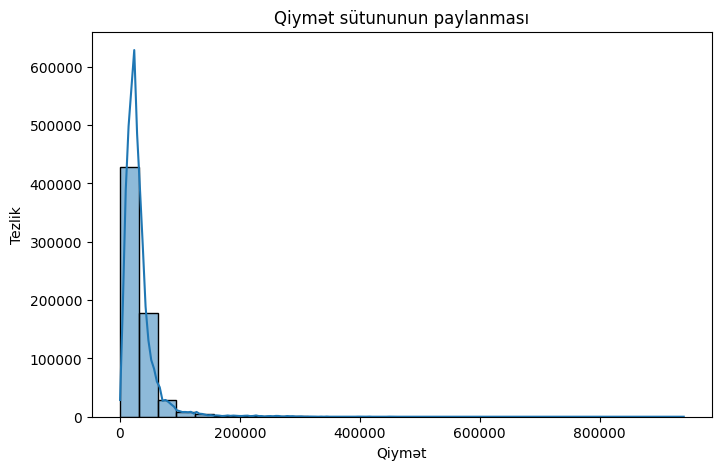

In [135]:
plt.figure(figsize=(8,5))
sns.histplot(df["Qiymət_2"], bins=30, kde=True)
plt.title("Qiymət sütununun paylanması")
plt.xlabel("Qiymət")
plt.ylabel("Tezlik")
plt.show()

Avtomobillərin böyük hissəsi aşağı və orta qiymət intervalında cəmləşmişdir. Qiymət artdıqca elanların sayı kəskin şəkildə azalır və sağ tərəfdə uzun quyruq əmələ gəlir. Bu isə paylanmanın sağa meyilli (positive skewed) olduğunu və yüksək qiymətli avtomobillərin az sayda olduğunu göstərir.

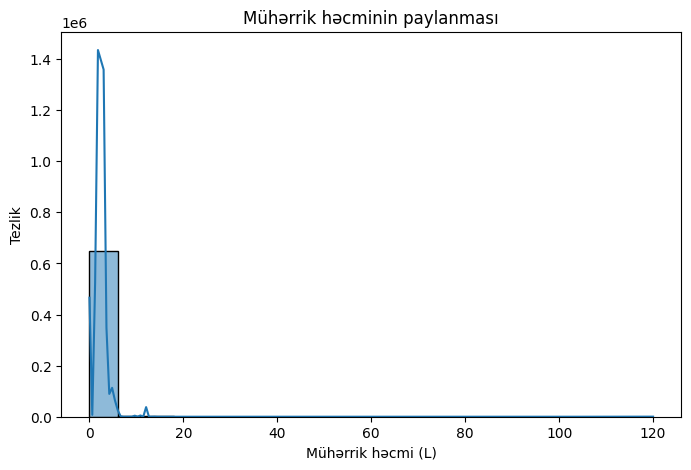

In [136]:
plt.figure(figsize=(8,5))
sns.histplot(df["Mühərrik_həcmi"], bins=20, kde=True)
plt.title("Mühərrik həcminin paylanması")
plt.xlabel("Mühərrik həcmi (L)")
plt.ylabel("Tezlik")
plt.show()

Avtomobillərin əksəriyyətinin mühərrik həcmi 1–3 litr intervalında cəmləşmişdir. Daha böyük mühərrik həcminə malik avtomobillərin sayı isə olduqca azdır və qrafikdə sağ tərəfdə uzun quyruq müşahidə olunur. Bu da paylanmanın sağa meyilli olduğunu göstərir.

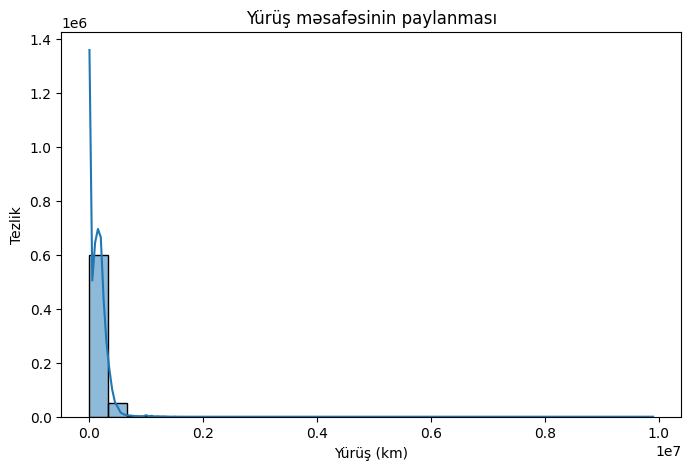

In [140]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Yürüş(km)"], bins=30, kde=True)
plt.title("Yürüş məsafəsinin paylanması")
plt.xlabel("Yürüş (km)")
plt.ylabel("Tezlik")
plt.show()

Avtomobillərin böyük əksəriyyətinin yürüş məsafəsi aşağı və orta intervalda cəmləşmişdir. Yürüş artdıqca elanların sayı kəskin şəkildə azalır və sağ tərəfdə uzun quyruq əmələ gəlir. Bu isə paylanmanın sağa meyilli (positive skewed) olduğunu göstərir.

# Hipotez Testi

## Biznes Sualı 1: Ötürücü Növünün Qiymətə Təsiri

Bazarda tam ötürücülü (4x4) avtomobillərin ön və ya arxa ötürücülü avtomobillərdən daha bahalı satıldığı fərz edilir. Bu sualın statistik olaraq təsdiqlənməsi qiymətləndirmə strategiyası və bazar seqmentasiyası üçün əhəmiyyətlidir.

**H₀ (Null hipotez)**:
Tam ötürücülü (4x4) avtomobillərin orta qiyməti ilə ön və ya arxa ötürücülü avtomobillərin orta qiymətləri arasında statistik cəhətdən əhəmiyyətli fərq yoxdur.

**H₁ (Alternativ hipotez)**:
Tam ötürücülü (4x4) avtomobillərin orta qiyməti ön və ya arxa ötürücülü avtomobillərin orta qiymətindən statistik cəhətdən əhəmiyyətli dərəcədə yüksəkdir.

In [141]:
df['Ötürücü'].value_counts()

,count
Ötürücü,
Ön,317028
Tam,187243
Arxa,149450


Hər üç qrupda kifayət qədər böyük nümunə var, statistik cəhətdən tam etibarlıdır.

In [142]:
from scipy.stats import kruskal

groups = [group['Qiymət_1'].dropna() for name, group in df.groupby('Ötürücü')]
stat, p_value = kruskal(*groups)
print(f"Statistika: {stat}")
print(f"p-dəyəri: {p_value}")

Statistika: 112781.789193997
p-dəyəri: 0.0


Statistika = 112781.79

p < 0.001

α = 0.05

p-dəyəri < α (0.05)

p-dəyəri (< 0.001) əhəmiyyət səviyyəsindən (α = 0.05) kiçik olduğu üçün H₀ rədd edilir (reject). Ötürücü növü (Ön / Arxa / Tam) ilə avtomobilin qiyməti arasında statistik cəhətdən çox güclü əhəmiyyətli əlaqə var.

In [145]:
!pip install scikit-posthocs

Ümumi test yalnız "ən azı bir qrup fərqlidir" məlumatını verir, hansı konkret cütlərin fərqləndiyini göstərmir. Bunu müəyyən etmək üçün üç cüt müqayisə aparılmalıdır (Ön-Arxa, Ön-Tam, Arxa-Tam). Korreksiyasız aparılan çoxsaylı testlər I növ xətanın (yalan-pozitiv) ehtimalını süni artırır. Bu səbəbdən Dunn post-hoc testi Bonferroni korreksiyası ilə tətbiq edirik.

In [146]:
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(df, val_col='Qiymət_1', group_col='Ötürücü', p_adjust='bonferroni')
print(posthoc)

              Arxa  Tam            Ön
Arxa  1.000000e+00  0.0  3.541368e-15
Tam   0.000000e+00  1.0  0.000000e+00
Ön    3.541368e-15  0.0  1.000000e+00


Hər üç ötürücü qrupu bir-birindən cüt-cüt statistik əhəmiyyətli şəkildə fərqlənir.

Nümunə ölçüsü çox böyük olduğundan (hər qrupda 149 000+), böyük data dəstlərində statistik əhəmiyyət (p-dəyəri) demək olar ki, avtomatik əldə olunur. Ona görə nəticənin praktiki mənasını qiymətləndirmək üçün median qiymətlərə baxaq:

In [147]:
df.groupby('Ötürücü')['Qiymət_1'].median().sort_values(ascending=False)

,Qiymət_1
Ötürücü,
Tam,36900.0
Arxa,22900.0
Ön,22000.0


Tam ötürücülü avtomobillərin median qiyməti yalnız ön və yalnız arxa ötürücülü avtomobillərdən ~68% yüksəkdir. Bu, statistik əhəmiyyətin sadəcə böyük nümunə ölçüsünün artefaktı olmadığını, real və biznes baxımından mənalı bir fərqi əks etdirdiyini göstərir.

# Nəticə

Kruskal-Wallis testi (H=112781.79, p<0.001) və onu izləyən Dunn post-hoc testi (Bonferroni korreksiyası ilə) hər üç ötürücü qrupu arasında statistik cəhətdən əhəmiyyətli qiymət fərqini təsdiqləyir. H₀ rədd edilir.

Praktiki baxımdan (effekt ölçüsü), fərq həqiqətən əhəmiyyətlidir: tam ötürücülü avtomobillərin median qiyməti yalnız ön və yalnız arxa ötürücülü avtomobillərdən təxminən 68% yüksəkdir. Bu, statistik əhəmiyyətin sadəcə böyük nümunə ölçüsünün artefaktı olmadığını, real bazar fərqini əks etdirdiyini göstərir.

Tam ötürücülü avtomobillərin daha bahalı olması qarışdırıcı dəyişənlərlə izah oluna bilər, belə ki, tam ötürücü tez-tez daha yeni buraxılış ili, daha güclü mühərrik və ya Offroader/SUV kimi özü də bahalı olan ban növləri ilə birlikdə rast gəlinir. Ötürücü növü qiyməti birbaşa müəyyən etmir, daha bahalı avtomobil seqmenti ilə əlaqəli olduğu üçün belə fərq müşahidə olunur.

## Biznes Sualı 2: Satıcı Növünün Avtomobil Qiymətinə Təsiri

Bazarda salon tərəfindən satılan avtomobillərin fərdi şəxslər tərəfindən satılan avtomobillərdən daha yüksək qiymətə təklif edildiyi fərz edilir. Bu fərziyyənin statistik olaraq yoxlanılması salon və fərdi satıcılar arasındakı qiymət fərqlərinin müəyyən edilməsi, bazarın qiymətləndirmə strategiyasının təhlili və alıcıların qərarvermə prosesinin daha yaxşı başa düşülməsi baxımından əhəmiyyətlidir.

**Null hipotez (H₀):**
Salon tərəfindən satılan avtomobillərin orta qiyməti ilə fərdi şəxslər tərəfindən satılan avtomobillərin orta qiyməti arasında statistik cəhətdən əhəmiyyətli fərq yoxdur.

**Alternativ hipotez (H₁):**
Salon tərəfindən satılan avtomobillərin orta qiyməti ilə fərdi şəxslər tərəfindən satılan avtomobillərin orta qiyməti arasında statistik cəhətdən əhəmiyyətli fərq vardır.

In [149]:
df['Salon'].value_counts()

,count
Salon,
0,460382
1,193339


Hər üç qrupda kifayət qədər böyük nümunə var, statistik cəhətdən tam etibarlıdır.

In [151]:
salon = df[df["Salon"] == 1]["Qiymət_2"]
fərdi = df[df["Salon"] == 0]["Qiymət_2"]

Hipotez testini seçməzdən əvvəl qiymət dəyişəninin hər iki qrup üzrə normal paylanıb-paylanmadığını müəyyən etmək üçün Shapiro–Wilk normallıq testini tətbiq edək:

In [152]:
from scipy.stats import shapiro

stat_salon, p_salon = shapiro(salon.sample(5000, random_state=42))
stat_ferdi, p_ferdi = shapiro(ferdi.sample(5000, random_state=42))

print("Salon p-value:", p_salon)
print("Fərdi p-value:", p_ferdi)

Salon p-value: 1.4835751347294606e-72
Fərdi p-value: 4.4398816529442775e-68


Salon üçün p = 1.48 × 10⁻⁷²

Fərdi satıcılar üçün p = 4.44 × 10⁻⁶⁸

Hər iki p-value 0.05-dən çox kiçikdir, yəni hər iki qrup normal paylanmır. t-test istifadə etmək düzgün deyil. Buna görə parametrik Independent Samples t-test əvəzinə qeyri-parametrik Mann–Whitney U testi tətbiq edək:

In [160]:
from scipy.stats import mannwhitneyu

u_stat, p_value = mannwhitneyu(
    salon,
    fərdi,
    alternative="two-sided"
)
print("U-statistic:", u_stat)
print("p-value:", p_value)

U-statistic: 63497893672.0
p-value: 0.0


U-statistic: 63497893672.0

p-value: 0.0 (praktik olaraq p < 0.001)

In [156]:
alpha = 0.05

if p_value < alpha:
    print("H0 rədd edilir (reject).")
    print("Salon və fərdi satıcılar tərəfindən satılan avtomobillərin qiymətləri arasında statistik cəhətdən əhəmiyyətli fərq vardır.")
else:
    print("H0 rədd edilə bilmir (fail to reject).")
    print("Salon və fərdi satıcılar tərəfindən satılan avtomobillərin qiymətləri arasında statistik cəhətdən əhəmiyyətli fərq yoxdur.")

H0 rədd edilir (reject).
Salon və fərdi satıcılar tərəfindən satılan avtomobillərin qiymətləri arasında statistik cəhətdən əhəmiyyətli fərq vardır.


p-value < 0.05 olduğu üçün H₀ (Null hipotez) rədd edilir (reject).
Salon və fərdi satıcılar tərəfindən satılan avtomobillərin qiymətləri arasında statistik cəhətdən əhəmiyyətli fərq vardır.

In [162]:
df.groupby("Salon")["Qiymət_2"].agg(["count", "mean", "median"])

,count,mean,median
Salon,,,
0,460382,25816.888242,22900.0
1,193339,45475.240505,34300.0


Həm orta, həm də median qiymətlərin salon qrupunda daha yüksək olması göstərir ki, salonlar tərəfindən satışa çıxarılan avtomobillər ümumilikdə fərdi satıcıların avtomobilləri ilə müqayisədə daha yüksək qiymətə təklif olunur.

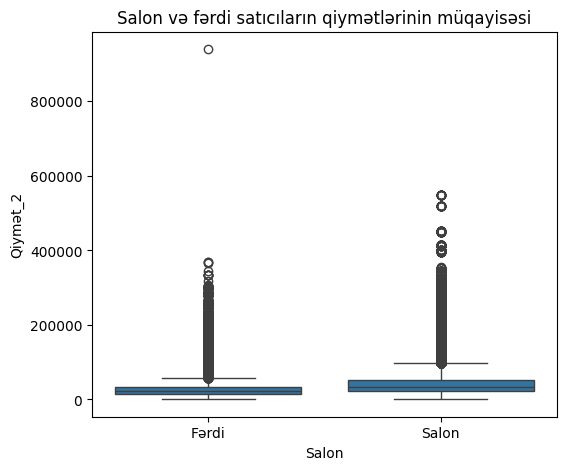

In [159]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x="Salon", y="Qiymət_2")
plt.xticks([0, 1], ["Fərdi", "Salon"])
plt.title("Salon və fərdi satıcıların qiymətlərinin müqayisəsi")
plt.show()

Salon tərəfindən satılan avtomobillərin median qiyməti fərdi şəxslər tərəfindən satılan avtomobillərin median qiymətindən daha yüksəkdir. Hər iki qrupda yüksək qiymətli ekstremal dəyərlər (outlier) mövcuddur, lakin fərdi satıcılarda daha yüksək qiymətli tək-tük elanlar da müşahidə olunur. Qrupların paylanmaları tam üst-üstə düşmədiyi üçün Mann–Whitney U testinin nəticəsi ilə uyğun olaraq salon və fərdi satıcılar arasında qiymət baxımından statistik cəhətdən əhəmiyyətli fərq olduğu qənaətinə gəlmək olar.

# Nəticə

Aparılan analiz nəticəsində Shapiro–Wilk normallıq testi hər iki qrup üzrə qiymətlərin normal paylanmadığını göstərdi (p < 0.05). Buna görə iki müstəqil qrupun müqayisəsi üçün Mann–Whitney U testi tətbiq edildi. Test nəticəsində H₀ hipotezi rədd edildi (p < 0.001) və salon tərəfindən satılan avtomobillərlə fərdi şəxslər tərəfindən satılan avtomobillərin qiymətləri arasında statistik cəhətdən əhəmiyyətli fərqin olduğu müəyyən edildi. Təsviri statistika və boxplot qrafiki də bu nəticəni dəstəklədi: salon tərəfindən satılan avtomobillərin həm orta, həm də median qiymətləri fərdi satıcılara aid avtomobillərlə müqayisədə daha yüksək olmuşdur. Bununla belə, bu nəticə satıcı növünün qiymətə səbəb olduğunu deyil, yalnız iki dəyişən arasında statistik cəhətdən əhəmiyyətli fərqin mövcud olduğunu göstərir.